In [15]:
import pandas as pd
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, pairwise_distances
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram, set_link_color_palette
import sys
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import to_hex
from scipy.spatial.distance import squareform
import numpy as np

# sys.path.insert(1, '../')
# from dict_types import *

sys.path.insert(1,'../4. CompareNormalisation')
from Functions import spaced_colors_from_cmap, compute_metric_sensitivity_by_resolution, plot_histograms, type_color_map_2, type_color_map_1
from MetricMapping import type_mapping, name_mapping

def clean_and_map(col):
    for metric in sorted(name_mapping.keys(), key=len, reverse=True):
        if col.startswith(metric):
            return name_mapping[metric]
    return col  # leave unchanged if no match

In [16]:
datadir = '/scratch/hydro4/users/kv25483/MetricEvaluation/Data/'
figdir = '/scratch/hydro4/users/kv25483/MetricEvaluation/Figures/'

## Read dataframe of results for all gauges

In [17]:
all_events_5mins = pd.read_csv(datadir+"IntermediateFiles/Just5m_raw_MinMaxScaled.csv")

column_names = all_events_5mins.columns.str.replace('_log', '')
column_names = column_names.str.replace('_yj', '')
all_events_5mins.columns = column_names

### Remove columns we're not interested in (rn)

In [18]:
cols_to_delete = ['duration',  'total_precip', 'min_intensity', 'time_std', 'ni']
for col in cols_to_delete:
    del all_events_5mins[col]

In [19]:
column_names = all_events_5mins.columns
column_names = column_names.str.replace('_wi', '')
all_events_5mins.columns = column_names

### Rename columns

In [20]:
all_events_5mins = all_events_5mins.rename(columns=lambda col: clean_and_map(col))

## Cluster analysis

In [21]:
data_for_clustering = all_events_5mins.T  
names = data_for_clustering.index

In [22]:
resolutions = ['10m', '30m', '60m']
resolution_colors = {'10m': '#1f77b4', '30m': '#ff7f0e', '60m': '#2ca02c'}

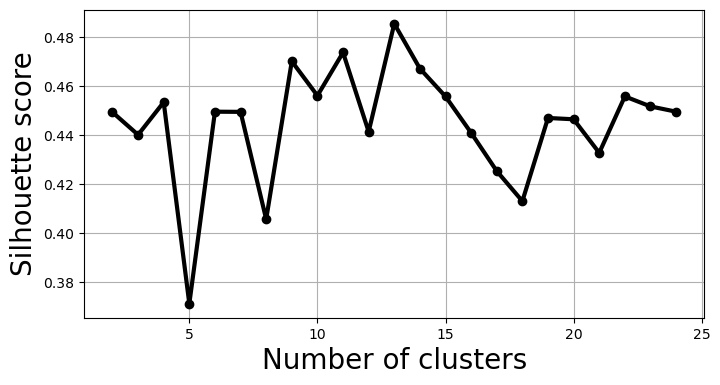

In [23]:
# Step 1: Compute correlation distance matrix (1 - Pearson correlation)
# corr = data_for_clustering.T.corr().abs()
corr = data_for_clustering.T.corr(method='spearman').abs()
dist_matrix = 1 - corr

# Step 2: Convert distance matrix to condensed form (for linkage)

condensed_dist = squareform(dist_matrix, checks=False)

# Step 3: Do clustering
Z = linkage(condensed_dist, method='average')  # Use 'average' for correlation distances
range_n_clusters = range(2, 25)
silhouette_scores = []

# Step 4: Evaluate silhouette scores manually
for n_clusters in range_n_clusters:
    labels = fcluster(Z, n_clusters, criterion='maxclust')

    # Use precomputed distance matrix for silhouette score
    score = silhouette_score(dist_matrix, labels, metric='precomputed')
    silhouette_scores.append(score)
# Plot the silhouette scores
fig, ax=plt.subplots(figsize=(8, 4))
plt.plot(range_n_clusters, silhouette_scores, marker='o', color='black')
plt.xlabel("Number of clusters", fontsize=20)
plt.ylabel("Silhouette score", fontsize=20)
plt.grid(True)
fig.savefig(figdir+ "silhoutte_scores.png", dpi=300, facecolor='white')

In [24]:
n_clusters= silhouette_scores.index(max(silhouette_scores)) + 2
n_clusters = 12

In [25]:
all_metric_names = names

# --- Assign types ---
metric_type_df = (
    pd.DataFrame({'metric': all_metric_names})
    .assign(type_2=lambda df: df['metric'].map(type_mapping)))

metric_type_df.fillna('Categorical', inplace=True)

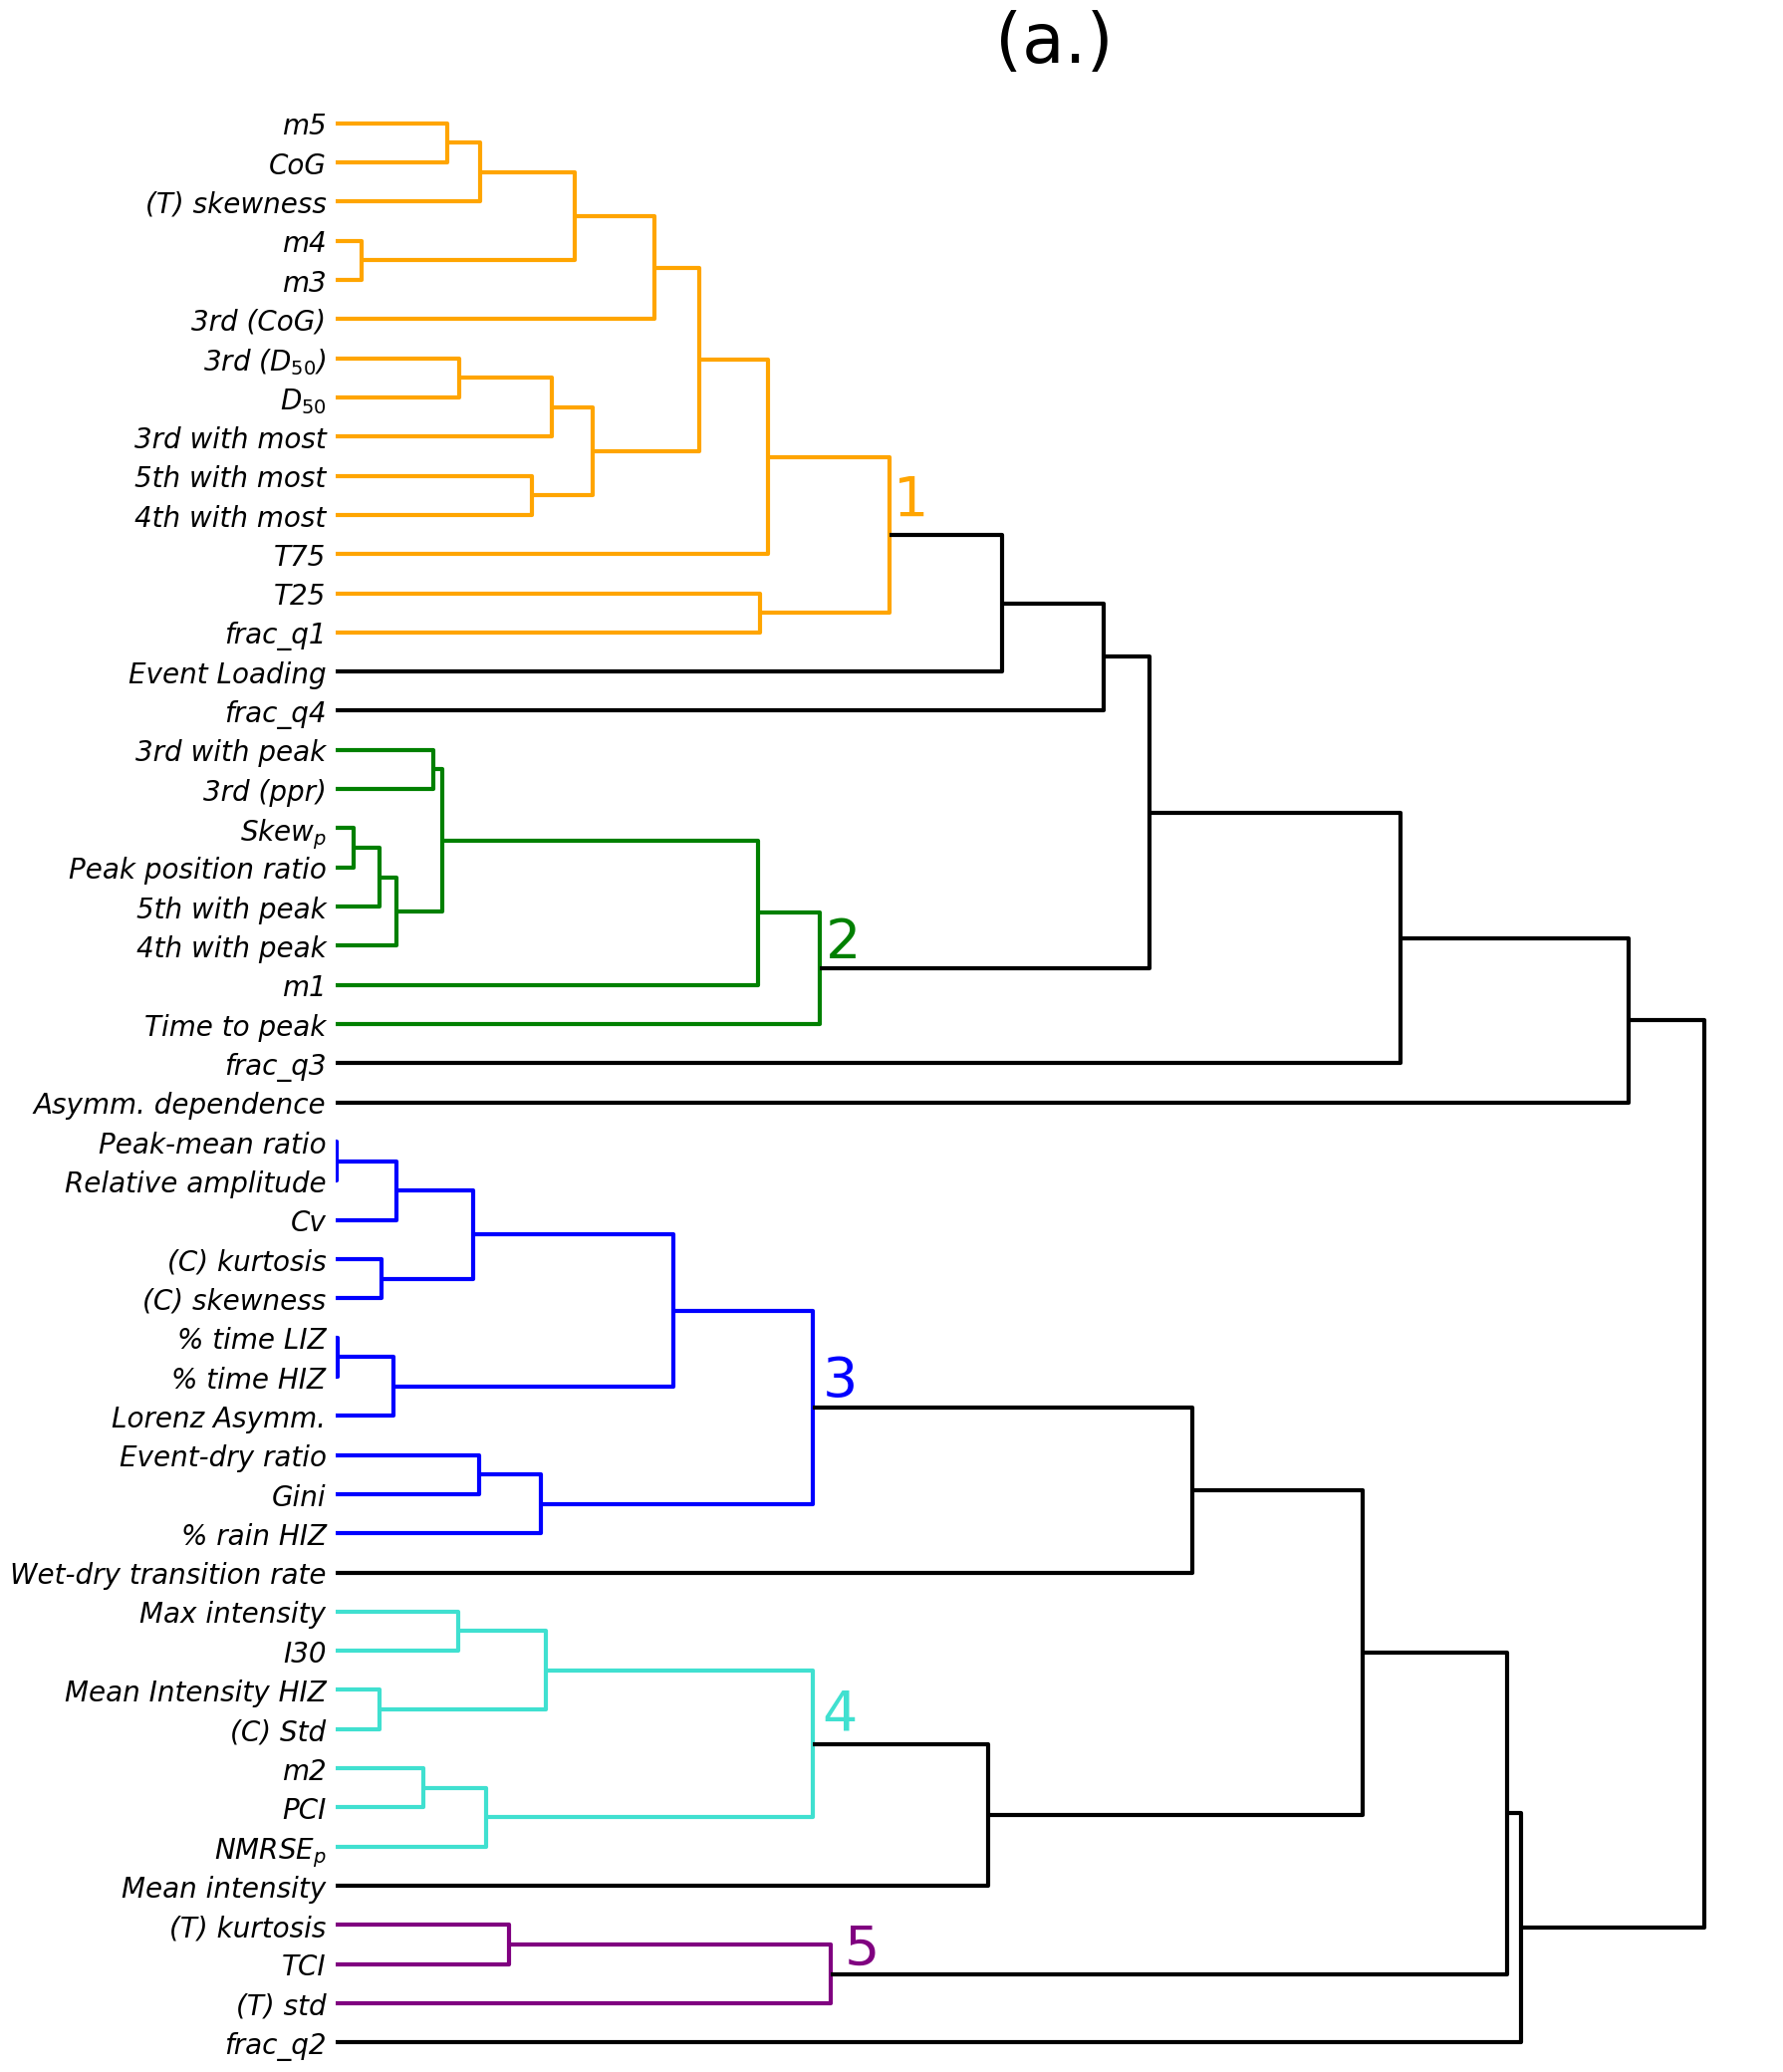

In [26]:
import matplotlib
matplotlib.rcParams['lines.linewidth'] =3
type_lookup = dict(zip(all_metric_names, metric_type_df['type_2']))

set_link_color_palette(['purple', 'turquoise', 'blue', 'green', 'orange','red'])

# 1 - absolute correlation → distance
corr = data_for_clustering.T.corr().abs()
dist = 1 - corr
dist_condensed = squareform(dist.values)  # convert to condensed form for linkage

Z = linkage(dist_condensed, method='average')  # or 'complete', 'single', etc.
n_clusters = n_clusters
threshold = Z[-(n_clusters - 1), 2] 
fig, ax = plt.subplots(figsize=(18, 23))
ddata = dendrogram(
    Z,
    labels=data_for_clustering.index,
    leaf_rotation=0,
    leaf_font_size=20,

    orientation='right',
    ax=ax,
    color_threshold=threshold,  # Use this instead of 0
    above_threshold_color='black')

ax.text(0.388, 395, '1', horizontalalignment='center', color='orange', size =40)
ax.text(0.342, 282, '2', horizontalalignment='center', color='green', size =40)
ax.text(0.34, 170, '3', horizontalalignment='center', color='blue', size =40)
ax.text(0.34, 85,'4', horizontalalignment='center', color='turquoise', size =40)
ax.text(0.355, 25, '5', horizontalalignment='center', color='purple', size =40)


# Title, layout
# ax.set_title(f'Hierarchical Clustering of Rainfall Metrics ({n_clusters} Clusters)', fontsize=16)
ax = plt.gca()

# Make the tick labels italic
for label in ax.get_yticklabels():
    label.set_fontstyle('italic')

# Hide all spines (box/frame)
for spine in ax.spines.values():
    spine.set_visible(False)

# Show only x-axis ticks and labels
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(True)  # hides y-axis ticks and labels

plt.subplots_adjust(bottom=0.2)  # 20% of the figure height as bottom margin

ax.set_title('(a.)', fontsize=50,  pad=30)
plt.tight_layout(rect=[0, 0.09, 1, 1])  # more space below
fig.savefig(figdir+"hierarchical_cluster.png", dpi=300, facecolor='white')
plt.show()

In [27]:
label_list = [label.get_text() for label in ax.get_yticklabels()]
label_list.reverse()

### Create correlation matrix

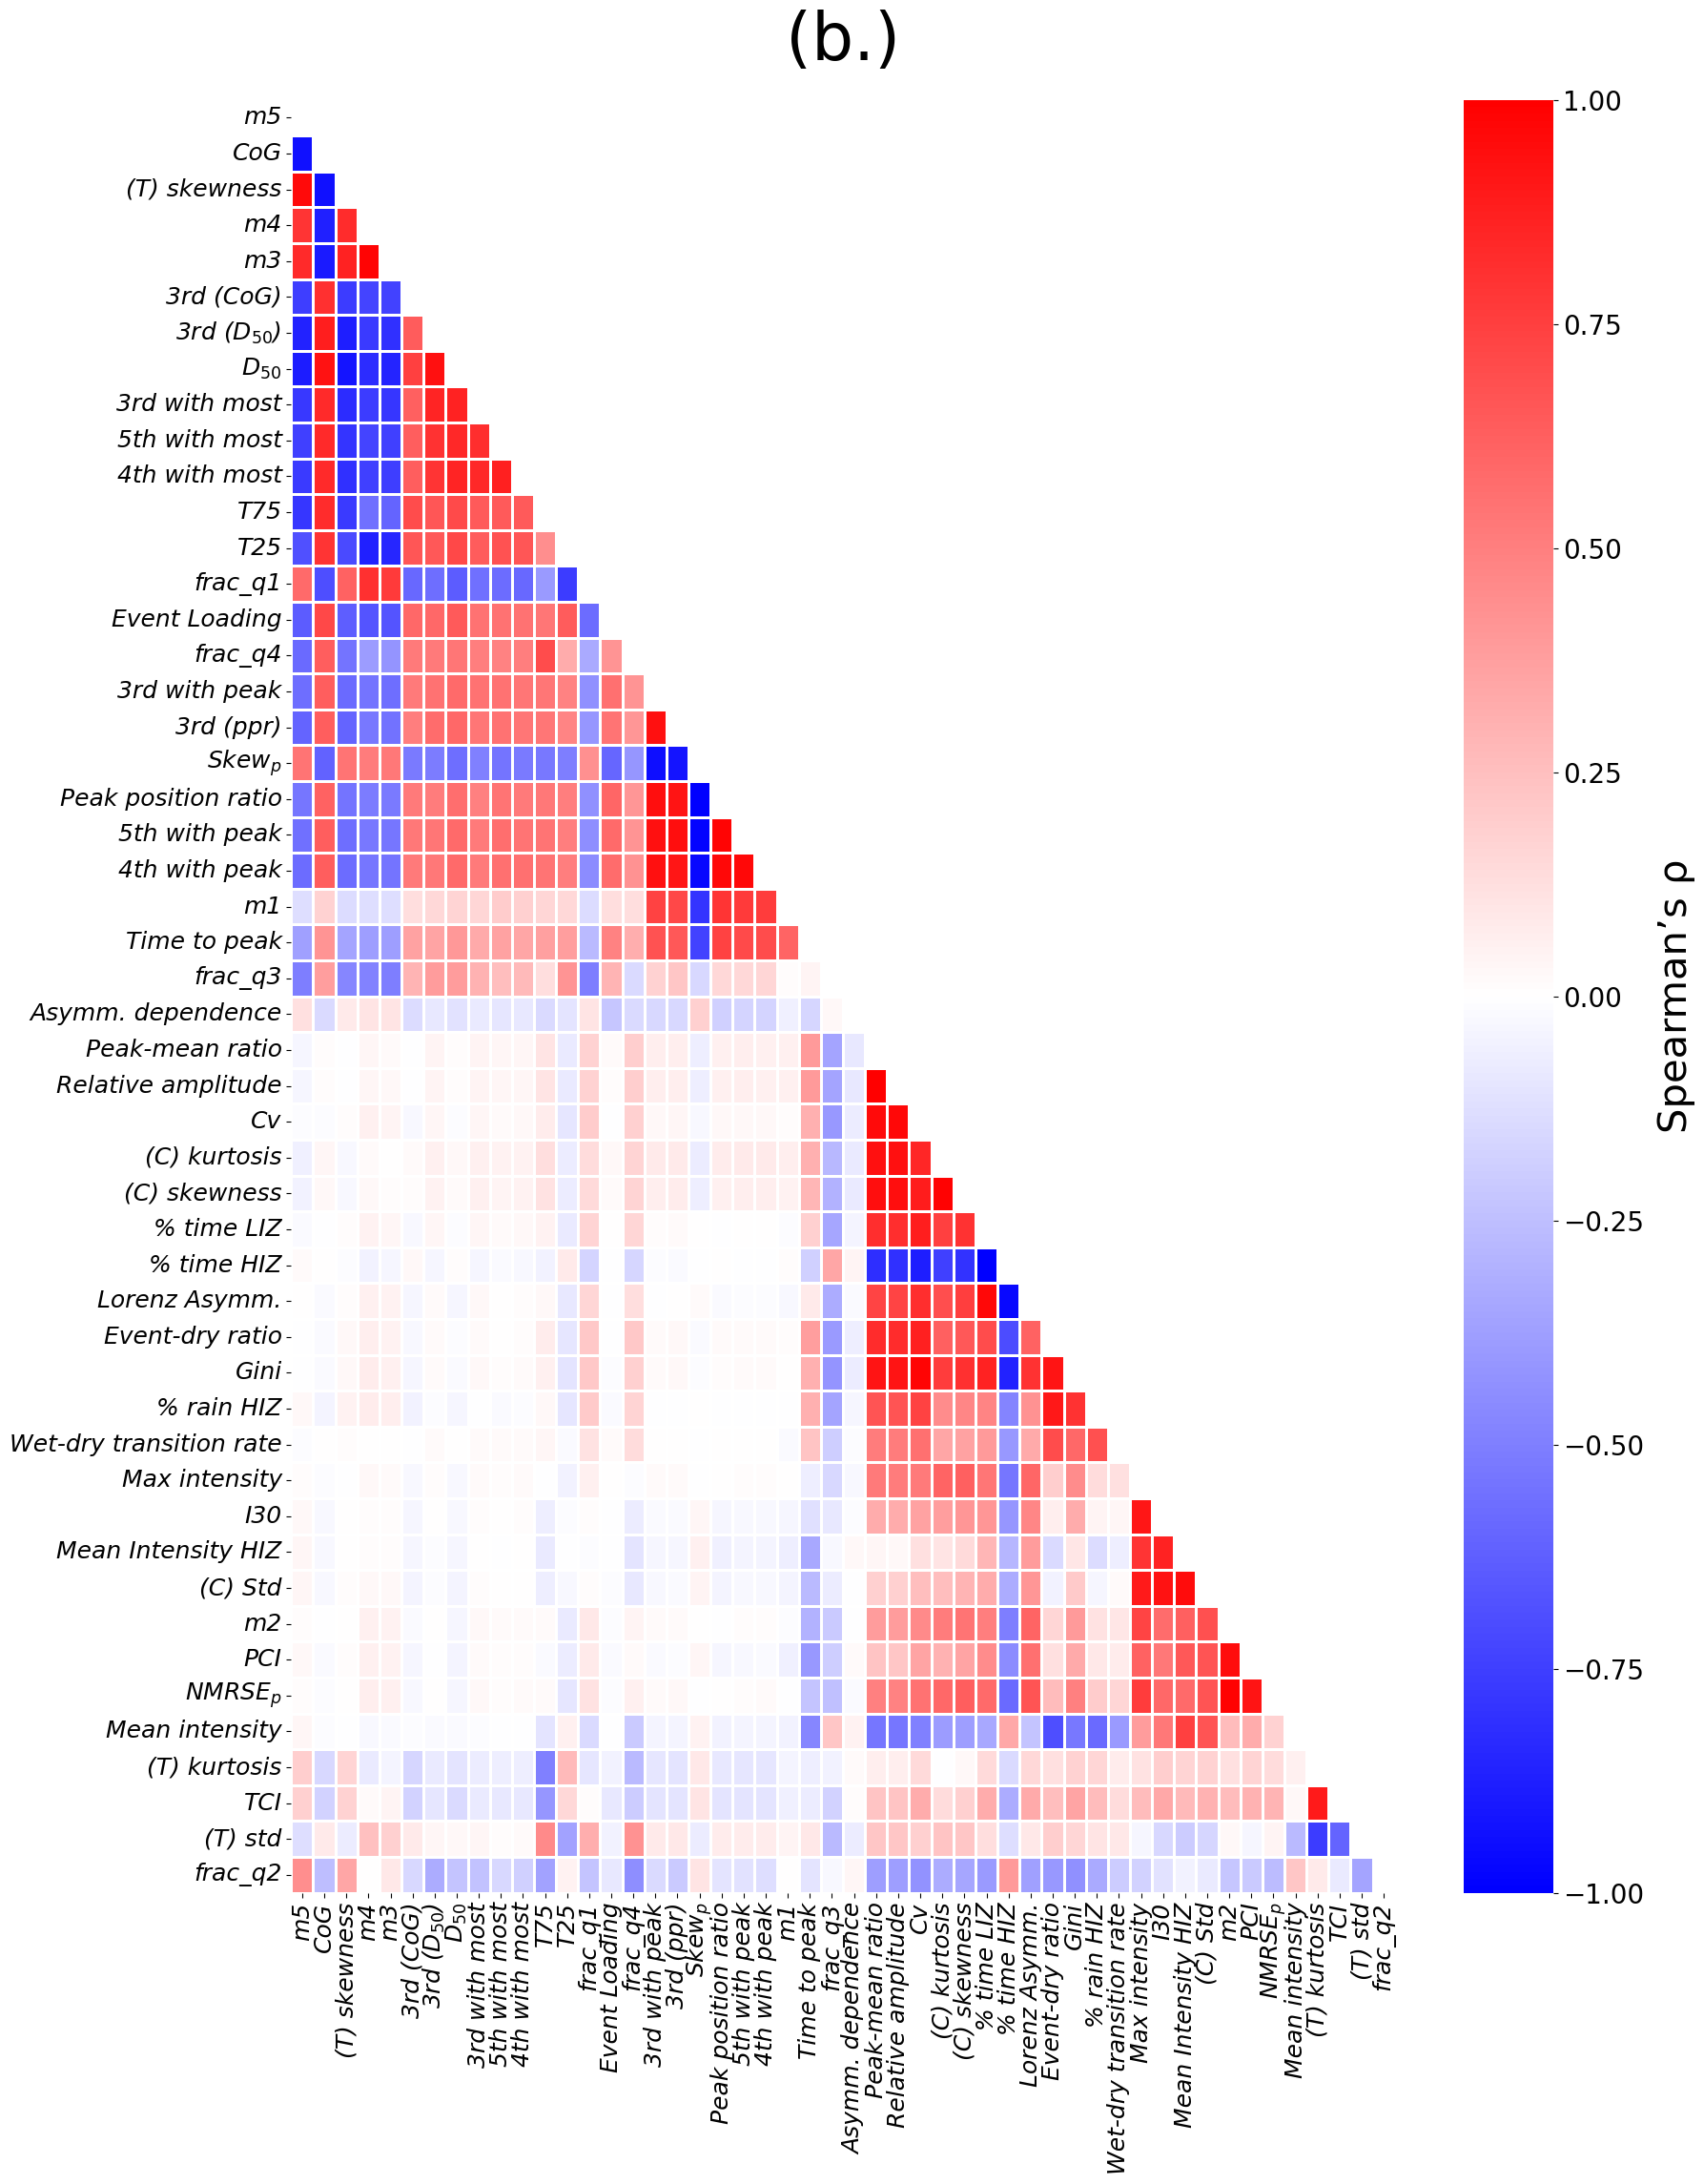

In [28]:
spearman_corr = all_events_5mins.corr(method='spearman')
# Reorder based on absolute total Spearman correlation strength
spearman_strength = spearman_corr.abs().sum().sort_values(ascending=False)
ordered_columns = spearman_strength.index.tolist()
reordered_spearman = spearman_corr.loc[label_list, label_list]

# Plot Spearman heatmap
fig,ax=plt.subplots(figsize=(18,23))
mask = np.triu(np.ones_like(reordered_spearman, dtype=bool))

heatmap = sns.heatmap(reordered_spearman,
    mask=mask,
    cmap='bwr',
    annot=False,
    fmt=".2f",
    linewidths=0.8,
    cbar=True,
    cbar_kws={"orientation": "vertical"},
    xticklabels=True,
    yticklabels=True,
    annot_kws={"size": 20},
    vmin=-1, vmax=1,
    ax=ax)

# Change colorbar tick label size
cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=20)  # <-- set size here

# Italicise tick labels
ax.set_xticklabels(ax.get_xticklabels(), fontstyle='italic', fontsize=18)
ax.set_yticklabels(ax.get_yticklabels(), fontstyle='italic', fontsize=18)

# Label the colorbar
cbar = heatmap.collections[0].colorbar
cbar.set_label("Spearman’s ρ", fontsize=30, labelpad=10)

plt.title("(b.)", fontsize=50, pad=30)
plt.tight_layout()
fig.savefig(figdir+ "correlation_matrix.png", dpi=300, facecolor='white', bbox_inches='tight')
plt.show()